### Import

In [37]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import csv
import re
from difflib import SequenceMatcher    
import Levenshtein
from skimage.metrics import structural_similarity as ssim

### HELPER FUCTION

In [38]:
# Fungsi untuk mengubah text menjadi bit
def text_to_bits(text):
    return ''.join(format(ord(c), '08b') for c in text)

# Fungsi untuk mengubah bit menjadi text
def bits_to_text(bits):
    chars = []
    for i in range(0, len(bits), 8):
        byte = bits[i:i+8]
        chars.append(chr(int(byte, 2)))
    return ''.join(chars)

### Esktrak Hasil LSB dari Citra

In [39]:
def extract_lsb(image_path):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"gagal membaca gambar: {image_path}")
        return None
    
    # Flatten semua piksel menjadi array 1D
    flat = img.flatten()
    total = len(flat)

    # Baca header (32 bit)
    header_bits = ""
    for i in range(32):                     # ambil 32 LSB pertama
        header_bits += str(flat[i] & 1)     # ambil bit terakhir (LSB)

    msg_len = int(header_bits, 2)           # convert 32 bit → integer

    # msg_len <= 0, maka tidak valid
    if msg_len <= 0:
        return "(Invalid payload)"

    # kapasitas minimal, yaitu 32 header + msg_len
    if 32 + msg_len > total:
        return "(Invalid payload)"

    bits = ""
    end = 32 + msg_len

    # Ambil bit pesan
    for i in range(32, end):
        bits += str(flat[i] & 1)

    # Jika panjang bit tidak sesuai msg_len → corrupted
    if len(bits) != msg_len:
        return "(Corrupted payload)"

    return bits_to_text(bits)   # decode bit → text

In [40]:
# Ekstrak LSB dari JPEG (sama seperti PNG, tapi JPEG cenderung rusak)
def extract_lsb_from_jpeg(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Gagal membaca gambar: {image_path}")
        return None
    
    flat = img.flatten()
    total = len(flat)

    # Baca header (32 bit)
    header_bits = ""
    for i in range(32):
        header_bits += str(flat[i] & 1)

    msg_len = int(header_bits, 2)
    if msg_len <= 0 or 32 + msg_len > total:
        return "(Invalid payload)"

    bits = ""
    for i in range(32, 32 + msg_len):
        bits += str(flat[i] & 1)

    if len(bits) != msg_len:
        return "(Corrupted payload)"

    return bits_to_text(bits)

In [41]:
# PSNR — Peak Signal-to-Noise Ratio
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 999
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

In [42]:
# Fungsi Menghitung Structural Similarity Index Measure
def compute_ssim(img1, img2):
    # convert BGR -> RGB for SSIM
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    score = ssim(img1_rgb, img2_rgb, channel_axis=2)
    return score

In [43]:
# --- Bit Error Rate ---
def bit_error_rate(original_text, extracted_text):
    orig_bits = text_to_bits(original_text)     # convert original → bit
    extr_bits = text_to_bits(extracted_text)    # convert extracted → bit

    min_len = min(len(orig_bits), len(extr_bits))
    errors = sum(1 for i in range(min_len) if orig_bits[i] != extr_bits[i]) # hitung bit berbeda
    total = len(orig_bits)                      # jumlah bit asli
    return errors / total if total > 0 else 0   # BER = error / total

In [44]:
# --- Text Similarity (SequenceMatcher) ---
def text_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio() * 100  # percentage

In [45]:
# --- Levenshtein Distance ---
def levenshtein_metrics(a, b):
    distance = Levenshtein.distance(a, b)
    max_len = max(len(a), len(b))
    normalized = (1 - distance / max_len) * 100 if max_len > 0 else 100
    return distance, normalized

### Simpan citra stego ke format JPEG dengan kualitas tertentu

In [46]:
def compress_jpeg(input_path, output_path, quality):
    img = cv2.imread(input_path)
    cv2.imwrite(output_path, img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])

### Fungsi Uji Kompresi

In [47]:
kualitas_list = [90, 50, 10]    # daftar kualitas JPEG yang akan diuji

def uji_kompresi(stego_folder, folder_out, kualitas_list):

    print("\n======================================================")
    print("        UJI ROBUSTNESS – KOMPRESI JPEG (LSB)")
    print("======================================================\n")

    os.makedirs("robustness_results", exist_ok=True)

    summary_all = {}

    for q in kualitas_list:

        print(f"\n==============================")
        print(f"Testing JPEG Quality = {q}")
        print(f"==============================\n")

        # ====== CSV UNTUK KUALITAS INI ======
        csv_path = os.path.join("robustness_results", f"compression_jpeg_q{q}.csv")
        with open(csv_path, "w", newline="", encoding="utf-8") as file:
            writer = csv.writer(file)
            writer.writerow([
                "File",
                "Kualitas(JPEG)",
                "PSNR",
                "SSIM",
                "BER",
                "Sequence Similarity(%)",
                "Levenshtein Distance",
                "Levenshtein Similarity(%)",
                "Snippet"
            ])

        # Statistik per kualitas
        psnr_list, ssim_list, ber_list, seqsim_list, levdist_list, levsim_list = [], [], [], [], [], []
        valid_count = 0
        invalid_count = 0
        corrupted_count = 0

        filenames = [f for f in os.listdir(stego_folder) if f.lower().endswith(".png")]

        # Folder output JPEG
        out_folder_q = os.path.join(folder_out, f"q{q}")
        os.makedirs(out_folder_q, exist_ok=True)

        for filename in filenames:

            path_stego = os.path.join(stego_folder, filename)
            name = os.path.splitext(filename)[0]

            # Kompres PNG → JPEG
            out_jpeg = os.path.join(out_folder_q, f"{name}_q{q}.jpg")
            compress_jpeg(path_stego, out_jpeg, q)

            # Ekstraksi pesan
            extracted = extract_lsb_from_jpeg(out_jpeg)
            original_msg = extract_lsb(path_stego)

            # ========== CLASSIFY RESULT ==========
            if extracted == "(Invalid payload)":

                # Hitung PSNR meskipun payload invalid
                ori = cv2.imread(path_stego)                        
                jpeg = cv2.imread(out_jpeg)

                psnr_val = psnr(ori, jpeg)
                ssim_val = compute_ssim(ori, jpeg)

                psnr_list.append(psnr_val)
                ssim_list.append(ssim_val)

                invalid_count += 1
                print(f"{filename}: INVALID PAYLOAD (header rusak)")

                with open(csv_path, "a", newline="", encoding="utf-8") as file:
                    writer = csv.writer(file)
                    writer.writerow([
                        filename, q, f"{psnr_val:.5f}", f"{ssim_val:.5f}", "", "", "", "", "(Invalid payload)"
                    ])
                continue

            elif extracted == "(Corrupted payload)":
                corrupted_count += 1
                print(f"{filename}: CORRUPTED PAYLOAD (header oke, isi rusak)")

                # Hitung PSNR meskipun corrupted
                ori = cv2.imread(path_stego)
                jpeg = cv2.imread(out_jpeg)

                psnr_val = psnr(ori, jpeg)
                ssim_val = compute_ssim(ori, jpeg)

                psnr_list.append(psnr_val)
                ssim_list.append(ssim_val)

                with open(csv_path, "a", newline="", encoding="utf-8") as file:
                    writer = csv.writer(file)
                    writer.writerow([
                        filename, q, f"{psnr_val:.5f}", f"{ssim_val:.5f}", "", "", "", "", "(Corrupted payload)"
                    ])
                continue

            else:
                valid_count += 1

            # ========= NORMAL METRIC PROCESSING ==========
            ber = bit_error_rate(original_msg, extracted)
            sim_ratio = text_similarity(original_msg, extracted)
            lev_dist, lev_sim = levenshtein_metrics(original_msg, extracted)

            ori = cv2.imread(path_stego)
            jpeg = cv2.imread(out_jpeg)
            psnr_val = psnr(ori, jpeg)
            ssim_val = compute_ssim(ori, jpeg)

            # Print metric
            print(f"\nFile: {filename}")
            print(f"Quality: {q}")
            print(f"PSNR: {psnr_val:.5f} dB")
            print(f"SSIM: {ssim_val:.5f}")
            print(f"BER: {ber:.5f}")
            print(f"Sequence Similarity: {sim_ratio:.2f}%")
            print(f"Levenshtein Distance: {lev_dist:.5f} | Levenshtein Similarity: {lev_sim:.2f}%")
            print("------------------------------------------------------------")

            snippet = extracted[:200] + "..." if len(extracted) > 200 else extracted
            print(snippet)

            # Simpan ke CSV per kualitas
            with open(csv_path, "a", newline="", encoding="utf-8") as file:
                writer = csv.writer(file)
                writer.writerow([
                    filename,
                    q,
                    f"{psnr_val:.5f}",
                    f"{ssim_val:.5f}",
                    f"{ber:.5f}",
                    f"{sim_ratio:.2f}",
                    lev_dist,
                    f"{lev_sim:.2f}",
                    snippet
                ])

            # Tambahkan ke list summary
            psnr_list.append(psnr_val)
            ssim_list.append(ssim_val)
            ber_list.append(ber)
            seqsim_list.append(sim_ratio)
            levdist_list.append(lev_dist)
            levsim_list.append(lev_sim)

        # ========== SUMMARY PER QUALITY ==========
        total = len(filenames)
        print("\n===== EXTRACTION SUMMARY =====")
        print(f"JPEG Quality = {q}")
        print(f"Total images      : {total}")
        print(f"Valid extraction  : {valid_count} ({valid_count/total*100:.2f}%)")
        print(f"Invalid payload   : {invalid_count} ({invalid_count/total*100:.2f}%)")
        print(f"Corrupted payload : {corrupted_count} ({corrupted_count/total*100:.2f}%)")
        print("=================================\n")

        # if valid_count > 0:
        #     summary_all[q] = {
        #         "PSNR": sum(psnr_list)/valid_count,
        #         "BER": sum(ber_list)/valid_count,
        #         "SeqSim": sum(seqsim_list)/valid_count,
        #         "LevDist": sum(levdist_list)/valid_count,
        #         "LevSim": sum(levsim_list)/valid_count,
        #         "ValidPct": valid_count/total*100,
        #         "InvalidPct": invalid_count/total*100,
        #         "CorruptedPct": corrupted_count/total*100,
        #     }

        if len(psnr_list) > 0:
            summary_all[q] = {
                "PSNR": sum(psnr_list) / len(psnr_list),
                "SSIM": sum(ssim_list) / len(ssim_list),
                "BER": sum(ber_list)/valid_count if valid_count>0 else 0,
                "SeqSim": sum(seqsim_list)/valid_count if valid_count>0 else 0,
                "LevDist": sum(levdist_list)/valid_count if valid_count>0 else 0,
                "LevSim": sum(levsim_list)/valid_count if valid_count>0 else 0,
                "ValidPct": valid_count/total*100,
                "InvalidPct": invalid_count/total*100,
                "CorruptedPct": corrupted_count/total*100,
            }

        else:
            summary_all[q] = {
                "ValidPct": valid_count/total*100,
                "InvalidPct": invalid_count/total*100,
                "CorruptedPct": corrupted_count/total*100,
            }

    return summary_all


### Eksekusi Uji Kompresi

In [48]:
### Eksekusi Uji Kompresi
hasil = uji_kompresi(
    stego_folder="stego_batik",
    folder_out="compression_batik_jpeg",
    kualitas_list=kualitas_list
)

if __name__ == "__main__":

    # Dictionary untuk menyimpan rata-rata per kualitas JPEG
    avg_metrics = {}

    print("\n--- AVERAGE METRICS PER JPEG QUALITY ---")

    # Loop kualitas dan tampilkan rata rata metrics
    for q in kualitas_list:
        avg_metrics[q] = hasil[q]
        print(f"\nQuality {q}: {hasil[q]}")



        UJI ROBUSTNESS – KOMPRESI JPEG (LSB)


Testing JPEG Quality = 90

stego_1.png: INVALID PAYLOAD (header rusak)
stego_10.png: INVALID PAYLOAD (header rusak)
stego_11.png: INVALID PAYLOAD (header rusak)
stego_12.png: INVALID PAYLOAD (header rusak)
stego_13.png: INVALID PAYLOAD (header rusak)
stego_14.png: INVALID PAYLOAD (header rusak)
stego_15.png: INVALID PAYLOAD (header rusak)
stego_16.png: INVALID PAYLOAD (header rusak)
stego_17.png: INVALID PAYLOAD (header rusak)
stego_18.png: INVALID PAYLOAD (header rusak)
stego_19.png: INVALID PAYLOAD (header rusak)
stego_2.png: INVALID PAYLOAD (header rusak)
stego_20.png: INVALID PAYLOAD (header rusak)
stego_21.png: INVALID PAYLOAD (header rusak)
stego_22.png: INVALID PAYLOAD (header rusak)
stego_23.png: INVALID PAYLOAD (header rusak)
stego_24.png: INVALID PAYLOAD (header rusak)
stego_25.png: INVALID PAYLOAD (header rusak)
stego_26.png: INVALID PAYLOAD (header rusak)
stego_27.png: INVALID PAYLOAD (header rusak)
stego_28.png: INVALID PAYLO

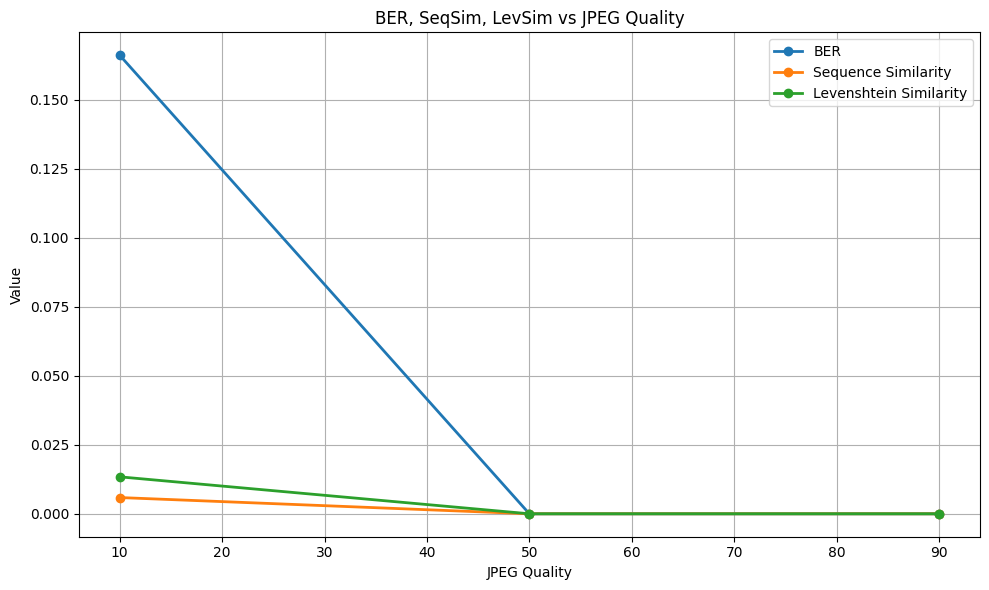

In [49]:
# VISUALISASI GRAFIK 
import matplotlib.pyplot as plt

valid_q = []
ber_vals = []
seq_vals = []
lev_vals = []

for q, metrics in hasil.items():
    if "BER" in metrics:  # pastikan hanya kualitas yang valid
        valid_q.append(q)
        ber_vals.append(metrics["BER"])
        seq_vals.append(metrics["SeqSim"] / 100)   # ubah ke 0–1 untuk grafik
        lev_vals.append(metrics["LevSim"] / 100)   # ubah ke 0–1 untuk grafik

plt.figure(figsize=(10, 6))

plt.plot(valid_q, ber_vals, marker="o", linewidth=2, label="BER")
plt.plot(valid_q, seq_vals, marker="o", linewidth=2, label="Sequence Similarity")
plt.plot(valid_q, lev_vals, marker="o", linewidth=2, label="Levenshtein Similarity")

plt.xlabel("JPEG Quality")
plt.ylabel("Value")
plt.title("BER, SeqSim, LevSim vs JPEG Quality")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()